/tmp/ipykernel_4119696/575276578.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['N', 'Randomness'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_4119696/575276578.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['N', 'Randomness'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_4119696/575276578.py:47: FutureWarning: DataFrameGroupBy.apply operated on th

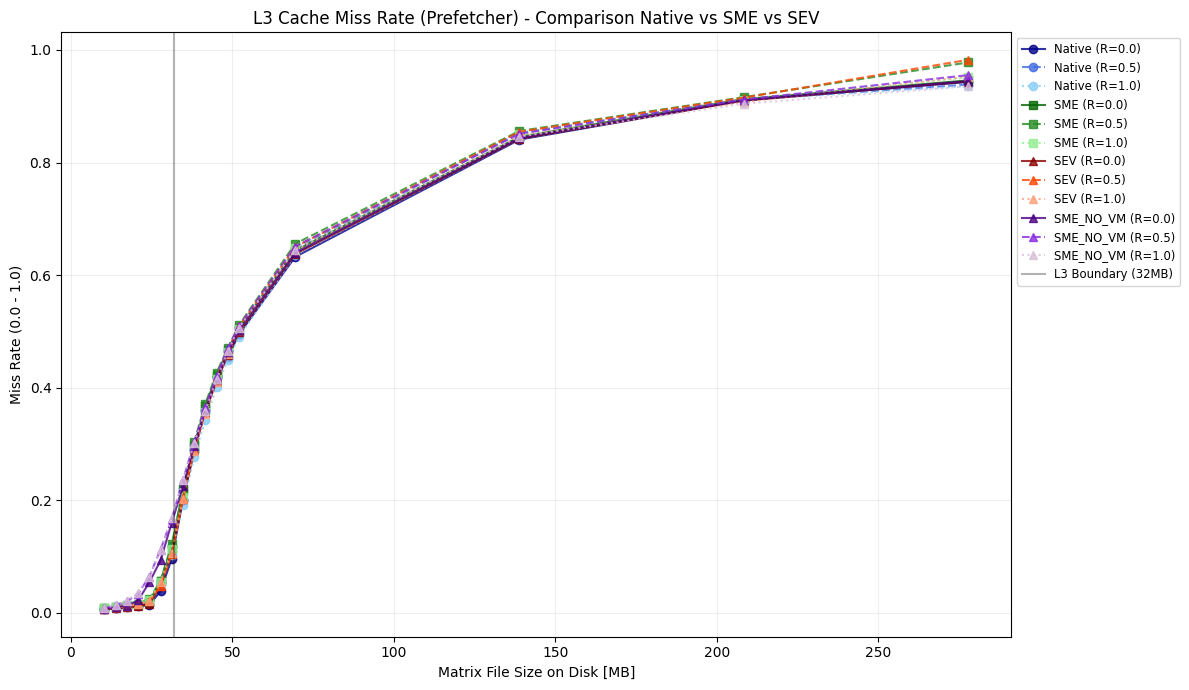

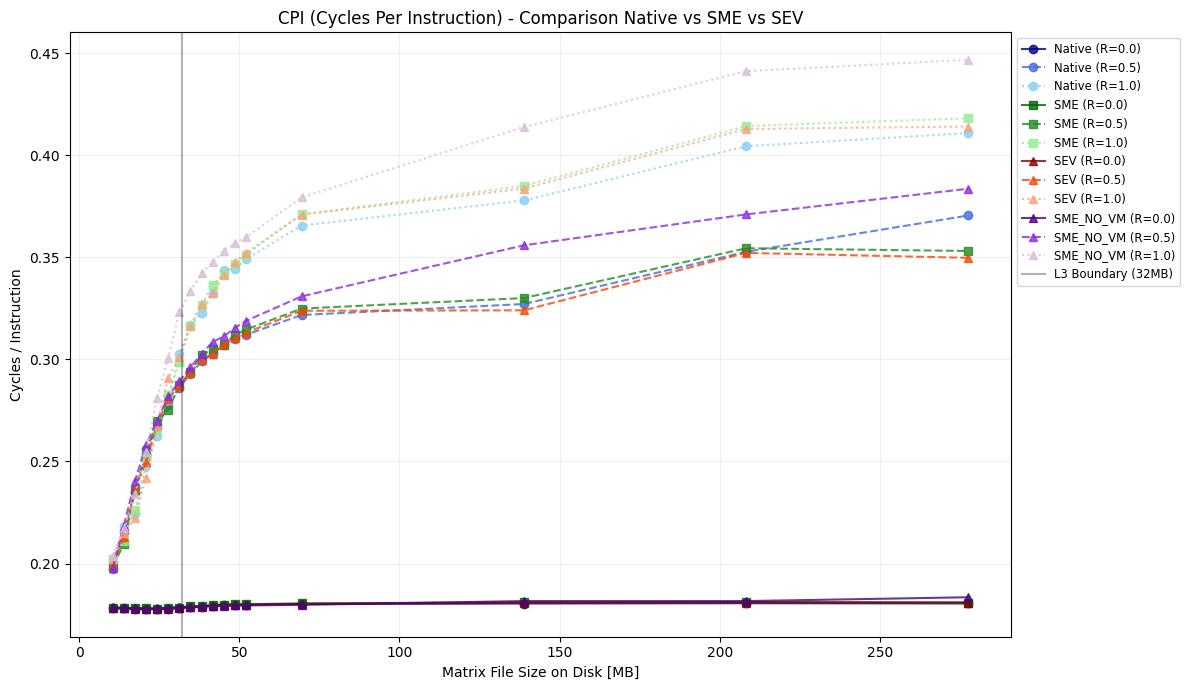

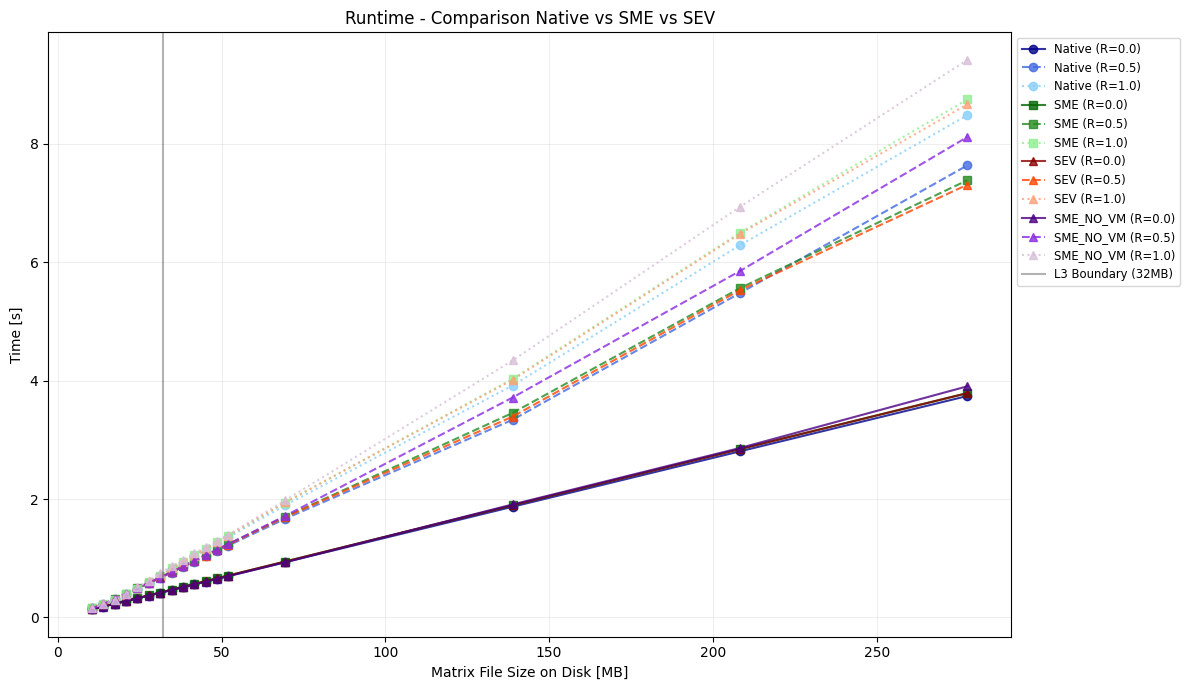

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Konfiguration: Pfade zu den CSVs
# Setze die Pfade auf None, falls du einen Typ noch nicht gemessen hast
files = {
    'Native': '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260202_155137/summary.csv',
    'SME':    '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260202_160256/summary.csv',
    'SEV':    '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260202_161448/summary.csv',
}
matrix_base_dir = '/home/mengelsl/MA-bench-framework/cachefit_testing/matrices'

# Farbschema definieren: Farbe pro Security-Typ
# Native = Blau-Töne, SME = Grün-Töne, SEV = Rot/Orange-Töne
color_map = {
    'Native': ['#00008B', '#4169E1', '#87CEFA'], # Dunkel bis Hellblau
    'SME':    ['#006400', '#228B22', '#90EE90'], # Dunkel bis Hellgrün
    'SEV':    ['#8B0000', '#FF4500', '#FFA07A'],  # Dunkel bis Hellrot/Orange
}

def load_and_clean(path, label):
    if not path or not os.path.exists(path):
        return None
    
    df = pd.read_csv(path)
    
    # Metriken berechnen (noch auf den Rohdaten)
    df['CPI'] = df['Clks'] / df['Inst']
    df['MissRate'] = df['L2_PF_Miss_L3'] / (df['L2_PF_Hit_L3'] + df['L2_PF_Miss_L3']).replace(0, 1)

    # --- OUTLIER TEST (IQR Methode) ---
    # Wir filtern Ausreißer innerhalb jeder Gruppe (N, Randomness), 
    # damit ein hoher Wert bei großer Matrix nicht als Ausreißer einer kleinen Matrix zählt.
    def remove_outliers(group):
        # Wir betrachten CPI als Hauptindikator für Ausreißer
        Q1 = group['CPI'].quantile(0.25)
        Q3 = group['CPI'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return group[(group['CPI'] >= lower_bound) & (group['CPI'] <= upper_bound)]

    # Filter pro Gruppe anwenden
    df = df.groupby(['N', 'Randomness'], group_keys=False).apply(remove_outliers)

    # Jetzt bilden wir den Median und die Standardabweichung (Varianz)
    # .agg erlaubt uns, beide Werte gleichzeitig zu berechnen
    df_stats = df.groupby(['N', 'Randomness']).agg({
        'CPI': ['median', 'std'],
        'MissRate': ['median', 'std'],
        'Runtime_s': ['median', 'std']
    }).reset_index()

    # Spaltennamen glätten (von Multi-Index zu einfachen Namen)
    df_stats.columns = ['N', 'Randomness', 'CPI_med', 'CPI_std', 'MR_med', 'MR_std', 'Runtime_med', 'Runtime_std']
    
    # MB berechnen (wie bisher)
    def get_mb(row):
        r_str = str(row['Randomness']).replace('.', '-')
        f_name = f"{r_str}_N{int(row['N'])}.bin"
        f_path = os.path.join(matrix_base_dir, f_name)
        return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None
    
    df_stats['MB'] = df_stats.apply(get_mb, axis=1)
    df_stats = df_stats.dropna(subset=['MB']).sort_values('MB')
    df_stats['Type'] = label
    
    return df_stats

# Daten laden
all_data = []
for label, path in files.items():
    data = load_and_clean(path, label)
    if data is not None:
        all_data.append(data)

full_df = pd.concat(all_data)
unique_r = sorted(full_df['Randomness'].unique())

# Plotting: Drei separate Figuren
metrics = ['MR_med', 'CPI_med', 'Runtime_med']
titles = ['L3 Cache Miss Rate (Prefetcher)', 'CPI (Cycles Per Instruction)', 'Runtime']
y_labels = ['Miss Rate (0.0 - 1.0)', 'Cycles / Instruction', 'Time [s]']

for i, metric in enumerate(metrics):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for label in files.keys():
        subset_type = full_df[full_df['Type'] == label]
        if subset_type.empty: continue
        
        for r_idx, r in enumerate(unique_r):
            subset = subset_type[subset_type['Randomness'] == r]
            # Wähle Farbe basierend auf Typ und Helligkeit basierend auf Randomness-Index
            color = color_map[label][r_idx % len(color_map[label])]
            
            ax.plot(subset['MB'], subset[metric], 
                    marker='o' if label == 'Native' else ('s' if label == 'SME' else '^'), 
                    linestyle='-' if r == 0.0 else ('--' if r == 0.5 else ':'),
                    color=color, 
                    label=f"{label} (R={r})",
                    alpha=0.8)

    ax.axvline(x=32, color='black', linestyle='-', alpha=0.3, label='L3 Boundary (32MB)')
    ax.set_xlabel('Matrix File Size on Disk [MB]')
    ax.set_ylabel(y_labels[i])
    ax.set_title(f"{titles[i]} - Comparison Native vs SME vs SEV")
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
    plt.tight_layout()
    
    # Speichern
    plt.savefig(f"plot_{metric.lower()}.png")
    plt.show()


In [61]:
# Varianzanalyse pro Datenpunkt
print("=== Varianzanalyse (Standardabweichung) ===\n")

for security_type in ['Native', 'SME', 'SEV']:
	subset = full_df[full_df['Type'] == security_type]
	
	print(f"\n{security_type}:")
	print("-" * 80)
	
	# Statistiken für CPI-Varianz
	print(f"CPI Standardabweichung:")
	print(f"  Min:    {subset['CPI_std'].min():.6f}")
	print(f"  Max:    {subset['CPI_std'].max():.6f}")
	print(f"  Median: {subset['CPI_std'].median():.6f}")
	print(f"  Mean:   {subset['CPI_std'].mean():.6f}")
	
	# Statistiken für MissRate-Varianz
	print(f"\nMiss Rate Standardabweichung:")
	print(f"  Min:    {subset['MR_std'].min():.6f}")
	print(f"  Max:    {subset['MR_std'].max():.6f}")
	print(f"  Median: {subset['MR_std'].median():.6f}")
	print(f"  Mean:   {subset['MR_std'].mean():.6f}")
	
	# Datenpunkte mit höchster Varianz
	print(f"\nTop 3 Datenpunkte mit höchster CPI-Varianz:")
	top_cpi = subset.nlargest(3, 'CPI_std')[['N', 'Randomness', 'MB', 'CPI_med', 'CPI_std']]
	print(top_cpi.to_string(index=False))
	
	print(f"\nTop 3 Datenpunkte mit höchster MissRate-Varianz:")
	top_mr = subset.nlargest(3, 'MR_std')[['N', 'Randomness', 'MB', 'MR_med', 'MR_std']]
	print(top_mr.to_string(index=False))

=== Varianzanalyse (Standardabweichung) ===


Native:
--------------------------------------------------------------------------------
CPI Standardabweichung:
  Min:    0.000015
  Max:    0.374526
  Median: 0.000867
  Mean:   0.036280

Miss Rate Standardabweichung:
  Min:    0.000093
  Max:    0.471635
  Median: 0.002337
  Mean:   0.059266

Top 3 Datenpunkte mit höchster CPI-Varianz:
     N  Randomness         MB  CPI_med  CPI_std
100000         1.0  34.713760 0.316688 0.374526
400000         0.5 138.854996 0.327110 0.370175
130000         1.0  45.127884 0.343749 0.361124

Top 3 Datenpunkte mit höchster MissRate-Varianz:
     N  Randomness         MB   MR_med   MR_std
800000         0.0 277.709976 0.943216 0.471635
800000         1.0 277.709976 0.935954 0.426690
800000         0.5 277.709976 0.938605 0.425025

SME:
--------------------------------------------------------------------------------
CPI Standardabweichung:
  Min:    0.000034
  Max:    0.008784
  Median: 0.000765
  Mean:   0